In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the California Housing dataset
data = fetch_california_housing(as_frame=True)

# Combine features and target into one table
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# Show first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# X = input features (everything except price)
X = df.drop("HousePrice", axis=1)

# y = what we want to predict (house price)
y = df["HousePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [5]:
# Create the scaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)

print("Before scaling - first row:", X.values[0])
print("After scaling - first row:", X_scaled[0])

Before scaling - first row: [   8.3252       41.            6.98412698    1.02380952  322.
    2.55555556   37.88       -122.23      ]
After scaling - first row: [ 2.34476576  0.98214266  0.62855945 -0.15375759 -0.9744286  -0.04959654
  1.05254828 -1.32783522]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

print("Models ready:", list(models.keys())

_IncompleteInputError: incomplete input (33677576.py, line 7)

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

print("Models ready:", list(models.keys()))

Models ready: ['Linear Regression', 'Ridge Regression', 'Decision Tree']


In [9]:
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Calculate metrics
    rmse = mean_squared_error(y_test, predictions, squared=False)
    r2 = r2_score(y_test, predictions)
    
    # Store results
    results[name] = {"RMSE": round(rmse, 4), "R2 Score": round(r2, 4)}
    
    print(f"{name} → RMSE: {rmse:.4f} | R²: {r2:.4f}")

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Calculate metrics
    rmse = mean_squared_error(y_test, predictions, squared=False)
    r2 = r2_score(y_test, predictions)
    
    # Store results
    results[name] = {"RMSE": round(rmse, 4), "R2 Score": round(r2, 4)}
    
    print(f"{name} → RMSE: {rmse:.4f} | R²: {r2:.4f}")

In [10]:
import numpy as np

results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Calculate metrics (updated for newer sklearn)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # Store results
    results[name] = {"RMSE": round(rmse, 4), "R2 Score": round(r2, 4)}
    
    print(f"{name} → RMSE: {rmse:.4f} | R²: {r2:.4f}")

Linear Regression → RMSE: 0.7456 | R²: 0.5758
Ridge Regression → RMSE: 0.7456 | R²: 0.5758
Decision Tree → RMSE: 0.7242 | R²: 0.5997


In [11]:
results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.7456,0.5758
Ridge Regression,0.7456,0.5758
Decision Tree,0.7242,0.5997


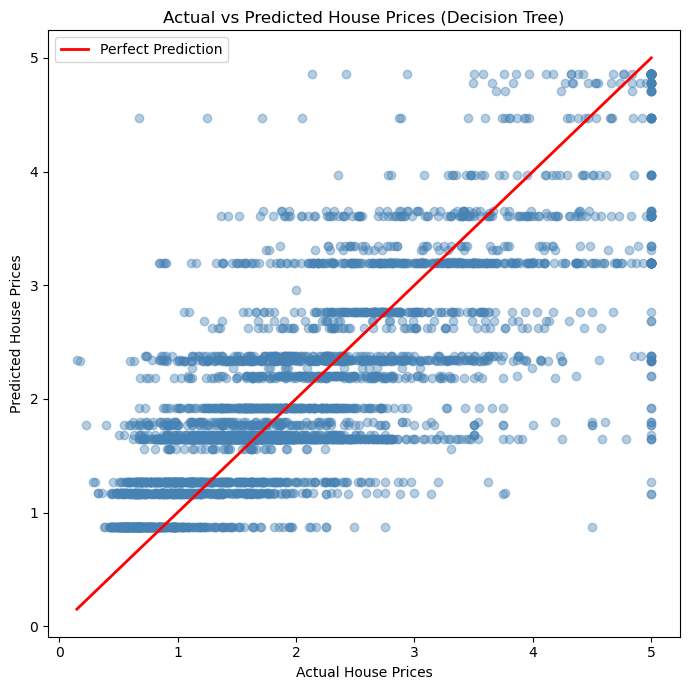

In [12]:
# Train the best model (Decision Tree)
best_model = DecisionTreeRegressor(max_depth=5)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Plot
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Decision Tree)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
import joblib

joblib.dump(best_model, "best_model.pkl")
print("Model saved successfully!")

Model saved successfully!


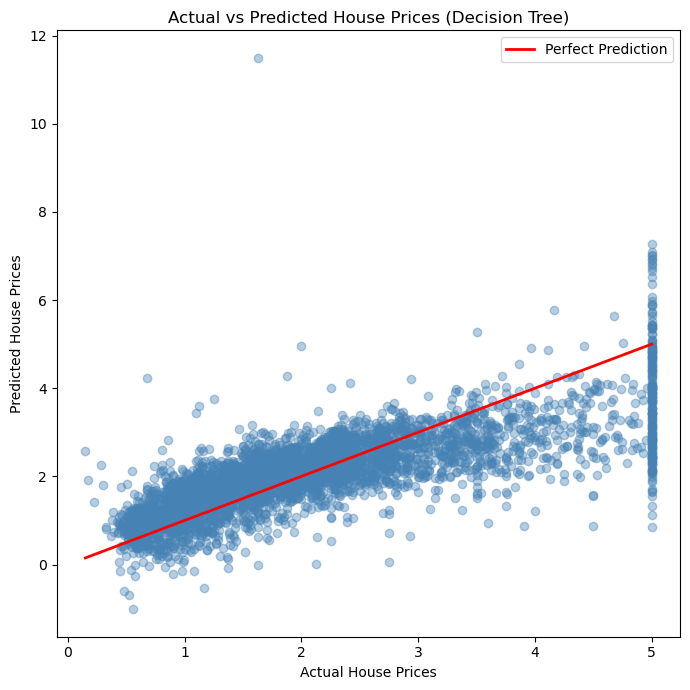

In [14]:
# Train the best model (Decision Tree)
best_model = Ridge(alpha=1.0)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Plot
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Decision Tree)")
plt.legend()
plt.tight_layout()
plt.show()

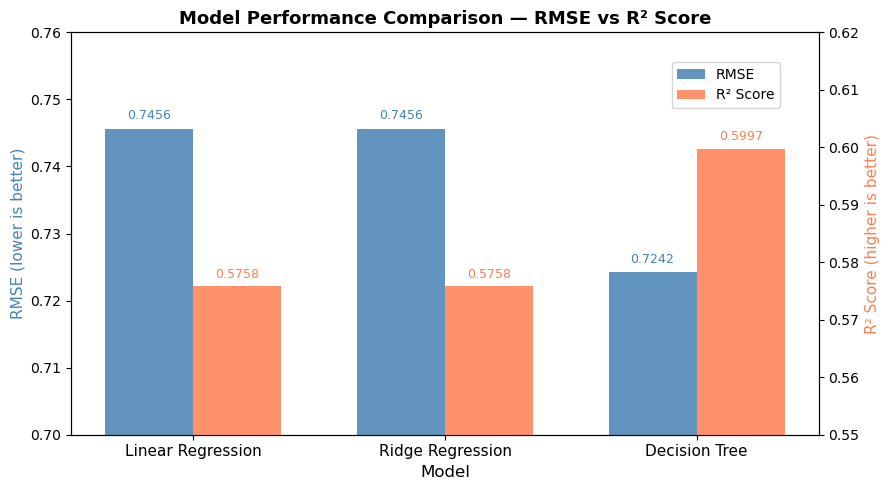

In [15]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Linear Regression', 'Ridge Regression', 'Decision Tree']
rmse_scores = [0.7456, 0.7456, 0.7242]
r2_scores = [0.5758, 0.5758, 0.5997]

x = np.arange(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(9, 5))

bars1 = ax1.bar(x - width/2, rmse_scores, width, label='RMSE', color='steelblue', alpha=0.85)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, r2_scores, width, label='R² Score', color='coral', alpha=0.85)

ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('RMSE (lower is better)', color='steelblue', fontsize=11)
ax2.set_ylabel('R² Score (higher is better)', color='coral', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.set_ylim(0.70, 0.76)
ax2.set_ylim(0.55, 0.62)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, color='steelblue')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, color='coral')

fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.title('Model Performance Comparison — RMSE vs R² Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                 'Population', 'AveOccup', 'Latitude', 'Longitude']

importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], color='steelblue', alpha=0.85)
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=11)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Decision Tree — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

AttributeError: 'Ridge' object has no attribute 'feature_importances_'

In [17]:
print(type(best_model))

<class 'sklearn.linear_model._ridge.Ridge'>


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                 'Population', 'AveOccup', 'Latitude', 'Longitude']

# Get feature importance scores
importances = best_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)),
         importances[indices],
         color='steelblue',
         alpha=0.85)

plt.yticks(range(len(indices)),
           [feature_names[i] for i in indices],
           fontsize=11)

plt.xlabel("Importance Score", fontsize=12)
plt.title("Decision Tree Feature Importance",
          fontsize=13,
          fontweight='bold')

plt.tight_layout()
plt.show()

AttributeError: 'Ridge' object has no attribute 'feature_importances_'

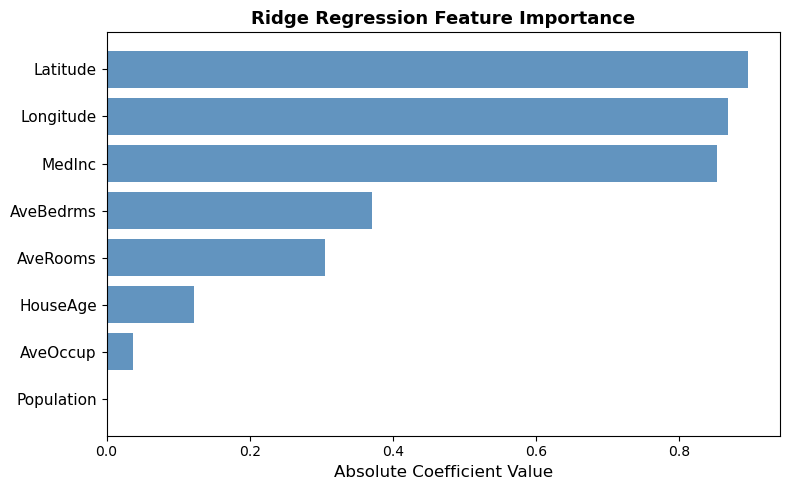

In [19]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                 'Population', 'AveOccup', 'Latitude', 'Longitude']

# Ridge feature importance using coefficients
importances = np.abs(best_model.coef_)

indices = np.argsort(importances)

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices],
         color='steelblue', alpha=0.85)

plt.yticks(range(len(indices)),
           [feature_names[i] for i in indices],
           fontsize=11)

plt.xlabel("Absolute Coefficient Value", fontsize=12)
plt.title("Ridge Regression Feature Importance",
          fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()